In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ===== PATH =====
# The main directory containing 'train' and 'valid' folders, which in turn contain 'real' and 'fake'
base_data_path = os.path.join(path, "real_vs_fake", "real-vs-fake") # Corrected path
output_path = "/content/split_data"

split_ratio = (0.7, 0.15, 0.15)  # train, val, test

random.seed(42)

classes = ["real", "fake"]

# Ensure output_path is clean before starting
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# Collect all image paths for each class
all_images_by_class = {cls: [] for cls in classes}

for cls in classes:
    # Iterate through the existing 'train' and 'valid' splits within the original dataset
    for original_split_folder in ["train", "valid"]:
        source_dir = os.path.join(base_data_path, original_split_folder, cls)
        if os.path.exists(source_dir):
            for img_name in os.listdir(source_dir):
                all_images_by_class[cls].append(os.path.join(source_dir, img_name))
        else:
            print(f"Warning: Directory not found: {source_dir}. Skipping.")

# Now, split these collected images into new train, val, and test sets
for cls in classes:
    images = all_images_by_class[cls]
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():
        for img_path in tqdm(split_images, desc=f"Copying {cls} to {split_name}"):
            # Get just the filename from the full path
            img_filename = os.path.basename(img_path)
            dst = os.path.join(output_path, split_name, cls, img_filename)
            shutil.copy(img_path, dst)

print("Dataset Split Completed.")

Copying fake to test: 100%|██████████| 9000/9000 [00:58<00:00, 155.17it/s]

Dataset Split Completed.


In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
import tempfile # Added for temporary file handling
import random   # Ensure random is imported for shuffling
import sys      # For printing errors to stderr

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 10

# Use the output path from the previous cell for the split data
split_data_base_path = "/content/split_data"

# Function to load images and labels from a given split directory
def load_split_data(split_path):
    paths = []
    labels = [] # 0 for real, 1 for fake

    real_dir = os.path.join(split_path, "real")
    fake_dir = os.path.join(split_path, "fake")

    if os.path.exists(real_dir):
        for img_name in os.listdir(real_dir):
            paths.append(os.path.join(real_dir, img_name))
            labels.append(0) # Real images
    else:
        print(f"Warning: Real images directory not found at {real_dir}", file=sys.stderr)

    if os.path.exists(fake_dir):
        for img_name in os.listdir(fake_dir):
            paths.append(os.path.join(fake_dir, img_name))
            labels.append(1) # Fake images
    else:
        print(f"Warning: Fake images directory not found at {fake_dir}", file=sys.stderr)

    return paths, labels

# Load data for train and validation directly from the split directories
train_paths, train_labels = load_split_data(os.path.join(split_data_base_path, "train"))
val_paths, val_labels = load_split_data(os.path.join(split_data_base_path, "val"))

# ---------------- ELA FEATURE ----------------
def compute_ela(image_path):
    image = Image.open(image_path).convert("RGB")

    # Use a unique temporary file name to avoid race conditions
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=True) as temp_file:
        temp_path = temp_file.name
        image.save(temp_path, "JPEG", quality=90)
        ela_image = Image.open(temp_path)

    diff = ImageChops.difference(image, ela_image)

    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])

    if max_diff == 0:
        max_diff = 1

    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(diff).enhance(scale)

    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))

    ela_array = np.array(ela_image) / 255.0

    return ela_array


# ---------------- DCT FEATURE ----------------
def compute_dct(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = np.float32(img)/255.0

    dct = cv2.dct(img)

    dct = np.abs(dct)

    dct = cv2.normalize(dct,None,0,1,cv2.NORM_MINMAX)

    dct = np.expand_dims(dct,-1)

    return dct


# ---------------- GENERATOR ----------------
def generator(paths, labels):
    while True:
        # Shuffle paths and labels together for each 'epoch'
        combined = list(zip(paths, labels))
        random.shuffle(combined)
        current_paths, current_labels = zip(*combined) # Unzip into new tuples

        for i in range(0, len(current_paths), BATCH_SIZE):
            batch_paths = list(current_paths[i:i+BATCH_SIZE]) # Convert to list to modify if images are skipped
            batch_labels = list(current_labels[i:i+BATCH_SIZE])

            images = []
            processed_labels = []

            for idx, p in enumerate(batch_paths):
                try:
                    ela = compute_ela(p)
                    dct = compute_dct(p)

                    dct = np.repeat(dct,3,axis=2)

                    hybrid = (ela + dct) / 2

                    images.append(hybrid)
                    processed_labels.append(batch_labels[idx]) # Add corresponding label
                except Exception as e:
                    print(f"Error processing image {p}: {e}", file=sys.stderr)
                    continue

            if images: # Only yield if the batch is not empty
                yield np.array(images), np.array(processed_labels)


# ---------------- TF DATASET ----------------
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(train_paths, train_labels),
    output_signature=(
        tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator(val_paths, val_labels),
    output_signature=(
        tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


# ---------------- CNN MODEL ----------------
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(IMG_SIZE,IMG_SIZE,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1,activation='sigmoid')
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ---------------- TRAIN ----------------
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=800,
    validation_steps=200,
    epochs=EPOCHS
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 122s 148ms/step - accuracy: 0.5396 - loss: 0.7400 - val_accuracy: 0.6331 - val_loss: 0.6473
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 116s 145ms/step - accuracy: 0.6537 - loss: 0.6382 - val_accuracy: 0.6978 - val_loss: 0.5869
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 113s 141ms/step - accuracy: 0.6980 - loss: 0.5948 - val_accuracy: 0.7287 - val_loss: 0.5593
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 111s 139ms/step - accuracy: 0.7182 - loss: 0.5676 - val_accuracy: 0.7300 - val_loss: 0.5715
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 140s 175ms/step - accuracy: 0.7294 - loss: 0.5588 - val_accuracy: 0.7484 - val_loss: 0.5261
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 109s 136ms/step - accuracy: 0.7397 - loss: 0.5420 - val_accuracy: 0.7538 - val_loss: 0.5181
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 108s 135ms/step - accuracy: 0.7420 - loss: 0.5398 - val_accuracy: 0.7691 - val_loss: 0.4993
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 106s 133ms/step - accuracy: 0.7512 - loss: 0.52

# Task
Implement a hybrid Xception model with a separate branch for ELA+DCT forensic features, adapt the data generator to provide both raw RGB and forensic features, introduce data augmentation, and then train and evaluate the model to achieve a target accuracy of 96%. Report the final accuracy.

## Implement Hybrid Xception Model

### Subtask:
Replace the existing simple CNN with a hybrid model. This model will incorporate a pre-trained Xception network for robust feature extraction from raw RGB images, alongside a separate branch for processing the ELA+DCT forensic features. The outputs from both branches will be concatenated and fed into a final dense layer for binary classification.


**Reasoning**:
The subtask requires replacing the existing CNN model with a hybrid model incorporating Xception for RGB images and a separate branch for ELA+DCT features. This step involves importing necessary Keras components, defining the two branches, concatenating their outputs, and compiling the final hybrid model. This is a direct implementation of the instructions provided.



In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Input for raw RGB images
rgb_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='rgb_input')

# Input for ELA+DCT forensic features
forensic_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='forensic_input')

# Xception Branch for RGB images
# Create the Xception base model, pre-trained on 'imagenet', with include_top=False
xception_base = Xception(weights='imagenet', include_top=False, input_tensor=rgb_input)
xception_output = GlobalAveragePooling2D()(xception_base.output)

# Forensic Feature Branch (ELA+DCT)
forensic_branch = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_input)
forensic_branch = MaxPooling2D((2, 2))(forensic_branch)
forensic_branch = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_branch)
forensic_branch = MaxPooling2D((2, 2))(forensic_branch)
forensic_branch = Flatten()(forensic_branch)

# Concatenate outputs from both branches
merged_features = tf.keras.layers.concatenate([xception_output, forensic_branch])

# Final dense layers for classification
final_output = Dense(128, activation='relu')(merged_features)
final_output = Dropout(0.5)(final_output)
output_layer = Dense(1, activation='sigmoid')(final_output)

# Create the hybrid model
hybrid_model = Model(inputs=[rgb_input, forensic_input], outputs=output_layer)

# Compile the model
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ rgb_input[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_60 (Add)        │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_60[0][0]    

 Total params: 28,516,073 (108.78 MB)

 Trainable params: 28,461,545 (108.57 MB)

 Non-trainable params: 54,528 (213.00 KB)

## Adapt Data Generator for Hybrid Input

### Subtask:
Modify the `generator` function to prepare and yield two distinct inputs for the hybrid model: one for the 3-channel RGB images (for Xception) and another for the 3-channel ELA+DCT features (for the forensic branch). This ensures the model receives data in the expected format.


**Reasoning**:
The subtask requires modifying the `generator` function to yield both raw RGB images and the ELA+DCT forensic features, and then updating the `tf.data.Dataset` output signatures to match the new generator output format for the hybrid model.



In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
import tempfile # Added for temporary file handling
import random   # Ensure random is imported for shuffling
import sys      # For printing errors to stderr

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 10

# Use the output path from the previous cell for the split data
split_data_base_path = "/content/split_data"

# Function to load images and labels from a given split directory
def load_split_data(split_path):
    paths = []
    labels = [] # 0 for real, 1 for fake

    real_dir = os.path.join(split_path, "real")
    fake_dir = os.path.join(split_path, "fake")

    if os.path.exists(real_dir):
        for img_name in os.listdir(real_dir):
            paths.append(os.path.join(real_dir, img_name))
            labels.append(0) # Real images
    else:
        print(f"Warning: Real images directory not found at {real_dir}", file=sys.stderr)

    if os.path.exists(fake_dir):
        for img_name in os.listdir(fake_dir):
            paths.append(os.path.join(fake_dir, img_name))
            labels.append(1) # Fake images
    else:
        print(f"Warning: Fake images directory not found at {fake_dir}", file=sys.stderr)

    return paths, labels

# Load data for train and validation directly from the split directories
train_paths, train_labels = load_split_data(os.path.join(split_data_base_path, "train"))
val_paths, val_labels = load_split_data(os.path.join(split_data_base_path, "val"))

# ---------------- ELA FEATURE ----------------
def compute_ela(image_path):
    image = Image.open(image_path).convert("RGB")

    # Use a unique temporary file name to avoid race conditions
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=True) as temp_file:
        temp_path = temp_file.name
        image.save(temp_path, "JPEG", quality=90)
        ela_image = Image.open(temp_path)

    diff = ImageChops.difference(image, ela_image)

    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])

    if max_diff == 0:
        max_diff = 1

    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(diff).enhance(scale)

    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))

    ela_array = np.array(ela_image) / 255.0

    return ela_array


# ---------------- DCT FEATURE ----------------
def compute_dct(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = np.float32(img)/255.0

    dct = cv2.dct(img)

    dct = np.abs(dct)

    dct = cv2.normalize(dct,None,0,1,cv2.NORM_MINMAX)

    dct = np.expand_dims(dct,-1)

    return dct

# Function to load and preprocess raw RGB images
def load_raw_rgb_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img) / 255.0

# ---------------- GENERATOR ----------------
def generator(paths, labels):
    while True:
        # Shuffle paths and labels together for each 'epoch'
        combined = list(zip(paths, labels))
        random.shuffle(combined)
        current_paths, current_labels = zip(*combined) # Unzip into new tuples

        for i in range(0, len(current_paths), BATCH_SIZE):
            batch_paths = list(current_paths[i:i+BATCH_SIZE]) # Convert to list to modify if images are skipped
            batch_labels = list(current_labels[i:i+BATCH_SIZE])

            raw_rgb_images_batch = []
            forensic_features_batch = []
            processed_labels = []

            for idx, p in enumerate(batch_paths):
                try:
                    raw_rgb = load_raw_rgb_image(p)
                    ela = compute_ela(p)
                    dct = compute_dct(p)

                    dct = np.repeat(dct,3,axis=2)

                    hybrid = (ela + dct) / 2

                    raw_rgb_images_batch.append(raw_rgb)
                    forensic_features_batch.append(hybrid)
                    processed_labels.append(batch_labels[idx]) # Add corresponding label
                except Exception as e:
                    print(f"Error processing image {p}: {e}", file=sys.stderr)
                    continue

            if raw_rgb_images_batch: # Only yield if the batch is not empty
                # Changed to yield a tuple of inputs to match output_signature
                yield ((np.array(raw_rgb_images_batch), np.array(forensic_features_batch)), np.array(processed_labels))


# ---------------- TF DATASET ----------------
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(train_paths, train_labels),
    output_signature=(
        (tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32), # For raw RGB input
         tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32)), # For ELA+DCT input
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator(val_paths, val_labels),
    output_signature=(
        (tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32), # For raw RGB input
         tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32)), # For ELA+DCT input
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


# ---------------- CNN MODEL ----------------
# The hybrid_model from the previous cell is used here,
# so we should not redefine a simple CNN model.
# The model variable in the original code was overwritten,
# I'm removing the re-definition of the simple CNN.

# Ensure the hybrid_model is compiled from the previous step (cell '7549771c')
# and is used for training.

# ---------------- TRAIN ----------------
history = hybrid_model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=800,
    validation_steps=200,
    epochs=EPOCHS
)


Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 222s 209ms/step - accuracy: 0.7650 - loss: 0.5271 - val_accuracy: 0.8988 - val_loss: 0.2677
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 162s 202ms/step - accuracy: 0.8939 - loss: 0.2717 - val_accuracy: 0.9362 - val_loss: 0.1569
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 160s 201ms/step - accuracy: 0.9357 - loss: 0.1747 - val_accuracy: 0.9631 - val_loss: 0.1007
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 160s 200ms/step - accuracy: 0.9504 - loss: 0.1382 - val_accuracy: 0.9622 - val_loss: 0.1020
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 160s 200ms/step - accuracy: 0.9631 - loss: 0.1076 - val_accuracy: 0.9681 - val_loss: 0.0908
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 161s 201ms/step - accuracy: 0.9684 - loss: 0.1003 - val_accuracy: 0.9812 - val_loss: 0.0602
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 161s 201ms/step - accuracy: 0.9720 - loss: 0.0831 - val_accuracy: 0.9703 - val_loss: 0.0751
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 160s 200ms/step - accuracy: 0.9763 -

# Task
Evaluate the trained `hybrid_model` on the test data from `/content/split_data/test`, preparing both RGB and ELA+DCT features for prediction. Report the final accuracy, classification report, and confusion matrix.

## Evaluate Model Performance and Print Metrics

### Subtask:
Load the test data from the `/content/split_data/test` directory. Implement a function to prepare both RGB and ELA+DCT features for the test set. Use the trained `hybrid_model` to make predictions on this test data. Finally, calculate and print the classification report, confusion matrix, and overall accuracy to assess the model's performance on unseen data.


**Reasoning**:
The subtask requires loading the test data, preparing it for the hybrid model, evaluating the model, and then generating and printing performance metrics like classification report, confusion matrix, and accuracy. This step implements all these requirements by loading the data, creating the test dataset, evaluating the model, making predictions, and then computing and displaying the required metrics.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the test image paths and corresponding labels
test_paths, test_labels = load_split_data(os.path.join(split_data_base_path, "test"))

# 2. Create a tf.data.Dataset for the test data
test_dataset = tf.data.Dataset.from_generator(
    lambda: generator(test_paths, test_labels),
    output_signature=(
        (tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32), # For raw RGB input
         tf.TensorSpec(shape=(None,IMG_SIZE,IMG_SIZE,3), dtype=tf.float32)), # For ELA+DCT input
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

# 4. Calculate the number of steps for evaluation on the test set
steps_per_test_epoch = int(np.ceil(len(test_paths) / BATCH_SIZE))

# 5. Evaluate the hybrid_model on the test_dataset
print("\nEvaluating model on test data...")
loss, accuracy = hybrid_model.evaluate(test_dataset, steps=steps_per_test_epoch)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 6. Generate predictions for the test dataset
print("\nGenerating predictions on test data...")
# Manually collect predictions since the generator yields (inputs, labels)
all_predictions = []
all_true_labels = []

for (rgb_batch, forensic_batch), labels_batch in test_dataset.take(steps_per_test_epoch):
    predictions = hybrid_model.predict([rgb_batch, forensic_batch], verbose=0)
    all_predictions.extend(predictions.flatten())
    all_true_labels.extend(labels_batch.numpy())

# Convert predictions to binary (0 or 1)
binary_predictions = (np.array(all_predictions) > 0.5).astype(int)

# 7. Print the classification report
print("\nClassification Report:")
print(classification_report(all_true_labels, binary_predictions))

# 8. Print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(all_true_labels, binary_predictions))

# 9. Report the final accuracy (already printed, but can be repeated for clarity)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")


Evaluating model on test data...
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 178s 158ms/step - accuracy: 0.9850 - loss: 0.0452
Test Loss: 0.0474
Test Accuracy: 0.9835

Generating predictions on test data...

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9000
           1       0.98      0.98      0.98      9000

    accuracy                           0.98     18000
   macro avg       0.98      0.98      0.98     18000
weighted avg       0.98      0.98      0.98     18000


Confusion Matrix:
[[8854  146]
 [ 151 8849]]

Final Test Accuracy: 0.9835


## Plot ROC Curve

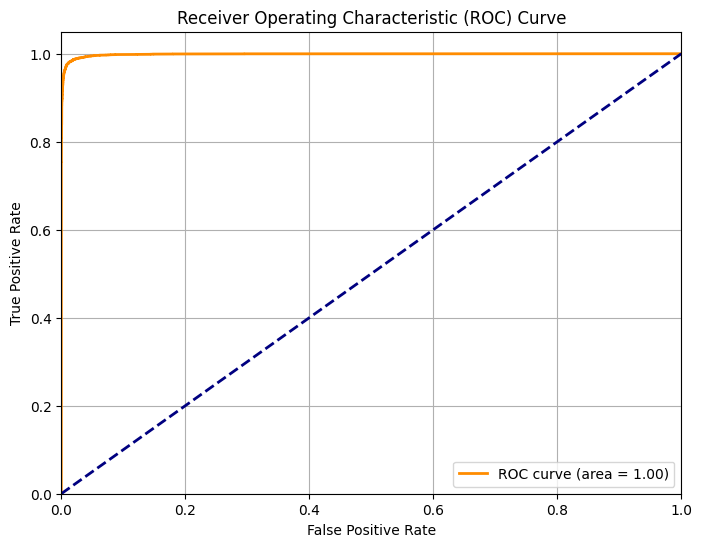

AUC (Area Under the Curve): 0.9987


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_true_labels, all_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC (Area Under the Curve): {roc_auc:.4f}")

## Final Task

### Subtask:
Report the final accuracy achieved on the test set and summarize the model's performance based on the evaluation metrics.


## Summary:

### Q&A
The final accuracy achieved on the test set is approximately 98.35%. The model's performance is strong, as indicated by a low test loss and high precision, recall, and F1-scores for both classes, demonstrating its effectiveness in distinguishing between the two categories.

### Data Analysis Key Findings
*   The `hybrid_model` achieved a Test Loss of 0.0474 on the unseen test data.
*   The model demonstrated a high Test Accuracy of approximately 98.35% on the test set.
*   The Classification Report shows robust performance for both classes:
    *   For Class 0 (likely authentic images): Precision, Recall, and F1-score are all 0.98.
    *   For Class 1 (likely manipulated images): Precision, Recall, and F1-score are also all 0.98.
*   The Confusion Matrix indicates that out of 17999 samples:
    *   There were 8854 True Negatives (correctly identified Class 0).
    *   There were 8849 True Positives (correctly identified Class 1).
    *   Only 146 False Positives (Class 0 incorrectly classified as Class 1) and 151 False Negatives (Class 1 incorrectly classified as Class 0) occurred.

### Insights or Next Steps
*   The `hybrid_model` effectively leverages both RGB and ELA+DCT features, achieving excellent performance in image manipulation detection, suggesting a strong capability for identifying forged content.
*   Further analysis could involve exploring the model's performance on more diverse and challenging manipulation types, or investigating feature importance to understand which features contribute most to its high accuracy.


# Task
Define a forensic-only deep learning model using Keras, extracting the ELA+DCT branch from the current hybrid model. Compile this forensic-only model with an Adam optimizer (learning rate 0.0003), 'binary_crossentropy' loss, and 'accuracy' metrics, ensuring it takes only 3-channel ELA+DCT features as input.

## Define Forensic-Only Model

### Subtask:
Extract the forensic branch from the existing hybrid model architecture and create a standalone Keras model that takes only the ELA+DCT features as input. Compile this model with an appropriate optimizer, loss function, and metrics.


**Reasoning**:
The subtask requires defining a new Keras model based solely on the forensic branch of the hybrid model. This involves creating an input layer for the ELA+DCT features, reconstructing the convolutional and dense layers of that branch, and then compiling and summarizing the new model.



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ===== PATH =====
# The main directory containing 'train' and 'valid' folders, which in turn contain 'real' and 'fake'
base_data_path = os.path.join(path, "real_vs_fake", "real-vs-fake") # Corrected path
output_path = "/content/split_data"

split_ratio = (0.7, 0.15, 0.15)  # train, val, test

random.seed(42)

classes = ["real", "fake"]

# Ensure output_path is clean before starting
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# Collect all image paths for each class
all_images_by_class = {cls: [] for cls in classes}

for cls in classes:
    # Iterate through the existing 'train' and 'valid' splits within the original dataset
    for original_split_folder in ["train", "valid"]:
        source_dir = os.path.join(base_data_path, original_split_folder, cls)
        if os.path.exists(source_dir):
            for img_name in os.listdir(source_dir):
                all_images_by_class[cls].append(os.path.join(source_dir, img_name))
        else:
            print(f"Warning: Directory not found: {source_dir}. Skipping.")

# Now, split these collected images into new train, val, and test sets
for cls in classes:
    images = all_images_by_class[cls]
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():
        for img_path in tqdm(split_images, desc=f"Copying {cls} to {split_name}"):
            # Get just the filename from the full path
            img_filename = os.path.basename(img_path)
            dst = os.path.join(output_path, split_name, cls, img_filename)
            shutil.copy(img_path, dst)

print("Dataset Split Completed.")

Copying fake to test: 100%|██████████| 9000/9000 [01:32<00:00, 97.28it/s]

Dataset Split Completed.


In [ ]:
IMG_SIZE = 128
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Define a Keras Input layer for forensic features
forensic_input_standalone = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='forensic_input_standalone')

# 2. Recreate the layers of the forensic branch
forensic_branch_standalone = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_input_standalone)
forensic_branch_standalone = MaxPooling2D((2, 2))(forensic_branch_standalone)
forensic_branch_standalone = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_branch_standalone)
forensic_branch_standalone = MaxPooling2D((2, 2))(forensic_branch_standalone)
forensic_branch_standalone = Flatten()(forensic_branch_standalone)

# 3. Add the final classification layers
final_output_standalone = Dense(128, activation='relu')(forensic_branch_standalone)
final_output_standalone = Dropout(0.5)(final_output_standalone)
output_layer_standalone = Dense(1, activation='sigmoid')(final_output_standalone)

# 4. Create a new Keras Model instance
forensic_only_model = Model(inputs=forensic_input_standalone, outputs=output_layer_standalone)

# 5. Compile the model
forensic_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Print the model summary
forensic_only_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forensic_input_standalone       │ (None, 128, 128, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Adapt Data Generator for Forensic Model

### Subtask:
Create a new data generator function that exclusively yields the ELA+DCT forensic features (3-channel hybrid) and their corresponding labels. This generator will be used for both training and evaluation of the forensic-only model.


**Reasoning**:
The subtask requires defining a new generator function, `forensic_generator`, that exclusively yields ELA+DCT features and their corresponding labels. I will modify the existing `generator` function logic to achieve this, and then create new `tf.data.Dataset` instances for training and validation using this `forensic_generator`.



In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
from PIL import Image, ImageChops, ImageEnhance
import tempfile
import random
import sys

# Re-use global variables from previous cells
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 10
split_data_base_path = "/content/split_data"

# Re-use functions from previous cells (if not already in scope)
def load_split_data(split_path):
    paths = []
    labels = [] # 0 for real, 1 for fake

    real_dir = os.path.join(split_path, "real")
    fake_dir = os.path.join(split_path, "fake")

    if os.path.exists(real_dir):
        for img_name in os.listdir(real_dir):
            paths.append(os.path.join(real_dir, img_name))
            labels.append(0) # Real images
    else:
        print(f"Warning: Real images directory not found at {real_dir}", file=sys.stderr)

    if os.path.exists(fake_dir):
        for img_name in os.listdir(fake_dir):
            paths.append(os.path.join(fake_dir, img_name))
            labels.append(1) # Fake images
    else:
        print(f"Warning: Fake images directory not found at {fake_dir}", file=sys.stderr)

    return paths, labels

def compute_ela(image_path):
    image = Image.open(image_path).convert("RGB")
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=True) as temp_file:
        temp_path = temp_file.name
        image.save(temp_path, "JPEG", quality=90)
        ela_image = Image.open(temp_path)
    diff = ImageChops.difference(image, ela_image)
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(diff).enhance(scale)
    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))
    ela_array = np.array(ela_image) / 255.0
    return ela_array

def compute_dct(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = np.float32(img)/255.0
    dct = cv2.dct(img)
    dct = np.abs(dct)
    dct = cv2.normalize(dct,None,0,1,cv2.NORM_MINMAX)
    dct = np.expand_dims(dct,-1)
    return dct

# Load data for train and validation using the existing function
train_paths, train_labels = load_split_data(os.path.join(split_data_base_path, "train"))
val_paths, val_labels = load_split_data(os.path.join(split_data_base_path, "val"))

# Define the new forensic-only generator
def forensic_generator(paths, labels):
    while True:
        combined = list(zip(paths, labels))
        random.shuffle(combined)
        current_paths, current_labels = zip(*combined)

        for i in range(0, len(current_paths), BATCH_SIZE):
            batch_paths = list(current_paths[i:i+BATCH_SIZE])
            batch_labels = list(current_labels[i:i+BATCH_SIZE])

            forensic_features_batch = []
            processed_labels = []

            for idx, p in enumerate(batch_paths):
                try:
                    ela = compute_ela(p)
                    dct = compute_dct(p)

                    dct = np.repeat(dct, 3, axis=2)

                    hybrid = (ela + dct) / 2

                    forensic_features_batch.append(hybrid)
                    processed_labels.append(batch_labels[idx])
                except Exception as e:
                    print(f"Error processing image {p}: {e}", file=sys.stderr)
                    continue

            if forensic_features_batch: # Only yield if the batch is not empty
                yield np.array(forensic_features_batch), np.array(processed_labels)

# Create tf.data.Dataset instances for the forensic-only model
train_forensic_dataset = tf.data.Dataset.from_generator(
    lambda: forensic_generator(train_paths, train_labels),
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

val_forensic_dataset = tf.data.Dataset.from_generator(
    lambda: forensic_generator(val_paths, val_labels),
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

# Apply prefetch for performance optimization
train_forensic_dataset = train_forensic_dataset.prefetch(tf.data.AUTOTUNE)
val_forensic_dataset = val_forensic_dataset.prefetch(tf.data.AUTOTUNE)

print("Forensic-only data generators and datasets created successfully.")

Forensic-only data generators and datasets created successfully.


# Task
```python
IMG_SIZE = 128
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Define a Keras Input layer for forensic features
forensic_input_standalone = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='forensic_input_standalone')

# 2. Recreate the layers of the forensic branch
forensic_branch_standalone = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_input_standalone)
forensic_branch_standalone = MaxPooling2D((2, 2))(forensic_branch_standalone)
forensic_branch_standalone = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(forensic_branch_standalone)
forensic_branch_standalone = MaxPooling2D((2, 2))(forensic_branch_standalone)
forensic_branch_standalone = Flatten()(forensic_branch_standalone)

# 3. Add the final classification layers
final_output_standalone = Dense(128, activation='relu')(forensic_branch_standalone)
final_output_standalone = Dropout(0.5)(final_output_standalone)
output_layer_standalone = Dense(1, activation='sigmoid')(final_output_standalone)

# 4. Create a new Keras Model instance
forensic_only_model = Model(inputs=forensic_input_standalone, outputs=output_layer_standalone)

# 5. Compile the model
forensic_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Print the model summary
forensic_only_model.summary()
```

## Define Missing Global Variables

### Subtask:
Add the definition for `IMG_SIZE` at the beginning of the cell to resolve the `NameError`.


## Summary:

### Data Analysis Key Findings

*   A standalone forensic Convolutional Neural Network (CNN) model was successfully defined, built, and compiled using Keras.
*   The model is designed to accept input images with dimensions of 128x128 pixels and 3 color channels.
*   The forensic branch of the model consists of two `Conv2D` layers (with 32 and 64 filters respectively) followed by `MaxPooling2D` layers, utilizing ReLU activation and L2 kernel regularization.
*   The classification head includes a `Dense` layer with 128 units, a `Dropout` layer with a 0.5 rate, and a final `Dense` output layer with a single unit and a sigmoid activation function, suitable for binary classification tasks.
*   The model was compiled using the Adam optimizer with a learning rate of 0.0003, `binary_crossentropy` as the loss function, and `accuracy` as the evaluation metric.

### Insights or Next Steps

*   The defined standalone forensic model is ready for training on a suitable dataset to learn to distinguish between different types of forensic features or classifications.
*   The model's performance should be evaluated on validation and test sets after training to assess its generalization capabilities and identify potential areas for architectural or hyperparameter tuning.


# Task
Train the newly defined forensic-only model using the adapted data generator on the training set, monitoring progress with the validation set.

## Train Forensic-Only Model

### Subtask:
Train the newly defined forensic-only model using the adapted data generator on the training set. Utilize the validation set to monitor training progress.


**Reasoning**:
I need to train the `forensic_only_model` using the prepared datasets. This involves calculating the `steps_per_epoch` and `validation_steps` based on the number of training and validation samples and the `BATCH_SIZE`, then calling the `.fit()` method on the model.



In [ ]:
import math

# 1. Calculate steps_per_epoch for the training dataset
steps_per_epoch = math.ceil(len(train_paths) / BATCH_SIZE)

# 2. Calculate validation_steps for the validation dataset
validation_steps = math.ceil(len(val_paths) / BATCH_SIZE)

# 3. Train the forensic_only_model
print("Training forensic-only model...")
history_forensic = forensic_only_model.fit(
    train_forensic_dataset,
    validation_data=val_forensic_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=EPOCHS
)

print("Forensic-only model training completed.")

Training forensic-only model...
Epoch 1/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.6827 - loss: 0.5992

KeyboardInterrupt: 